# 09 · A Real Small-Model SFT → DPO Lab

    [Course README](../README.md) · Created by Shivam Bharadwaj

    [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/09_small_model_sft_dpo.ipynb)

    **Goal:** Update an actual pretrained causal language model and distinguish preference margins from generation quality.

    Restart the kernel and run all cells. Local setup: install the root
    `requirements-modern.txt` first. On Colab, the setup cell clones the public course
    code into the runtime and installs the pinned modern dependencies.
    Readable implementation modules live in `rl_course/`; links below connect each experiment to its source.
    Code is MIT licensed; explanations and plots are CC BY 4.0. See the root LICENSE.

In [1]:
import sys, subprocess
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = Path.cwd() if (Path.cwd() / 'rl_course').exists() else Path.cwd().parent
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course').exists():
    raise FileNotFoundError('Clone the complete repository and open this notebook from its notebooks directory.')
if IN_COLAB and True:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(ROOT / 'requirements-modern.txt')], check=True)
sys.path.insert(0, str(ROOT))
import platform, numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline
torch.set_num_threads(2)
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({'figure.figsize': (10, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'text.color': INK,
    'axes.labelcolor': INK, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
                     '\n'.join('| ' + ' | '.join(str(value).replace('|', '&#124;').replace('\n', '<br>') for value in row) + ' |' for row in rows)))
print(f'Python {platform.python_version()} | NumPy {np.__version__} | PyTorch {torch.__version__} | CPU, 2 threads')

Python 3.12.4 | NumPy 2.5.3 | PyTorch 2.11.0+cpu | CPU, 2 threads


## 1. What is real, and what is deliberately small?

We load **SmolLM2-135M**, a public pretrained causal language model, at a pinned revision.
The task is sentiment classification with generated text: `positive` or `negative`.
Only its final decoder layer and final normalization are updated to keep the lab affordable.
This is real token-level model training, not a table of response logits, but it is not full-model
fine-tuning or evidence of general conversational alignment.

The pipeline is **pretrained model → SFT on demonstrations → synthetic preference pairs → DPO → held-out evaluation**.
The preference labels come from a controlled template, not humans. There is no learned reward
model in this DPO route. For a PPO-based RLHF route, a reward model and rollout/advantage machinery
would replace the direct pairwise objective.

**Resources:** first run downloads roughly 0.3 GB of model weights plus tokenizer files.
Allow several GB of host RAM, extra disk cache space, and several minutes on CPU. This notebook
intentionally uses CPU even when Colab offers a GPU. No paid API or account token is required.
Network access is needed for the initial public download. The model's Apache-2.0 terms remain
separate from the course licenses; see the [model card](https://huggingface.co/HuggingFaceTB/SmolLM2-135M).

Source: [mini_llm.py](../rl_course/mini_llm.py). Inspect `batch_tokens`, `completion_logps`, and `run`.

In [2]:
import transformers
from rl_course import mini_llm
print('Transformers', transformers.__version__)
table(['Setting', 'Value'], [['Model', mini_llm.MODEL_ID], ['Immutable revision', mini_llm.REVISION],
    ['Data', mini_llm.DATA_VERSION], ['Seed', 7], ['SFT steps / learning rate', '36 / 2e-4'],
    ['DPO steps / learning rate / beta', '24 / 5e-5 / .1'], ['Batch size', 4],
    ['Train/test prompts', '48 / 24; disjoint nouns, same template and adjective vocabulary']])

/tmp/rl-course-clean/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers 5.5.4


| Setting | Value |
|---|---|
| Model | HuggingFaceTB/SmolLM2-135M |
| Immutable revision | 93efa2f097d58c2a74874c7e644dbc9b0cee75a2 |
| Data | SyntheticSentiment-v1 |
| Seed | 7 |
| SFT steps / learning rate | 36 / 2e-4 |
| DPO steps / learning rate / beta | 24 / 5e-5 / .1 |
| Batch size | 4 |
| Train/test prompts | 48 / 24; disjoint nouns, same template and adjective vocabulary |

## 2. Completion masking and the frozen reference

SFT maximizes the probability of the demonstrated answer tokens plus EOS. Prompt and padding
tokens are masked out. DPO compares **summed completion log probabilities** for chosen and rejected
answers, relative to the frozen SFT policy. Using a mean instead changes the objective.

Because preference pairs are fixed, we cache their reference log probabilities once after SFT.
This avoids keeping a second model in RAM. These cached values are a reference distribution on
these pairs—not PPO's old policy and not a full KL measurement.

**Common Misconception:** a better chosen/rejected likelihood margin does not guarantee a better
free-running answer. We measure both held-out pair accuracy and exact generated-label accuracy.
The test split checks unseen nouns within a shared template, not broad language generalization.

In [3]:
result = mini_llm.run(seed=7, sft_steps=36, dpo_steps=24)
total, trained = result['parameter_counts']
print(f'Total parameters: {total:,}; trainable: {trained:,} ({100*trained/total:.2f}%)')
table(['Stage', 'Held-out pair accuracy', 'Generated-label accuracy', 'Pair margin',
       'Margin change from SFT', 'Training seconds'],
      [[r['stage'], f"{r['heldout_pair_accuracy']:.1%}", f"{r['heldout_generation_accuracy']:.1%}",
        f"{r['mean_pair_margin']:.3f}", '—' if r['margin_change_from_SFT'] is None else f"{r['margin_change_from_SFT']:.3f}", f"{r['training_seconds']:.1f}"]
       for r in result['rows']])

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 4352.27it/s]

{'stage': 'Pretrained', 'heldout_pair_accuracy': 1.0, 'heldout_generation_accuracy': 0.0, 'mean_pair_margin': 0.8188112378120422, 'margin_change_from_SFT': None, 'training_seconds': 0.0}


{'stage': 'SFT', 'heldout_pair_accuracy': 1.0, 'heldout_generation_accuracy': 1.0, 'mean_pair_margin': 1.444311499595642, 'margin_change_from_SFT': 0.0, 'training_seconds': 8.694997740007238}


{'stage': 'DPO', 'heldout_pair_accuracy': 1.0, 'heldout_generation_accuracy': 1.0, 'mean_pair_margin': 1.6825202703475952, 'margin_change_from_SFT': 0.23820871114730835, 'training_seconds': 11.514758784003789}


Total parameters: 134,515,008; trainable: 3,540,672 (2.63%)


| Stage | Held-out pair accuracy | Generated-label accuracy | Pair margin | Margin change from SFT | Training seconds |
|---|---|---|---|---|---|
| Pretrained | 100.0% | 0.0% | 0.819 | — | 0.0 |
| SFT | 100.0% | 100.0% | 1.444 | 0.000 | 8.7 |
| DPO | 100.0% | 100.0% | 1.683 | 0.238 | 11.5 |

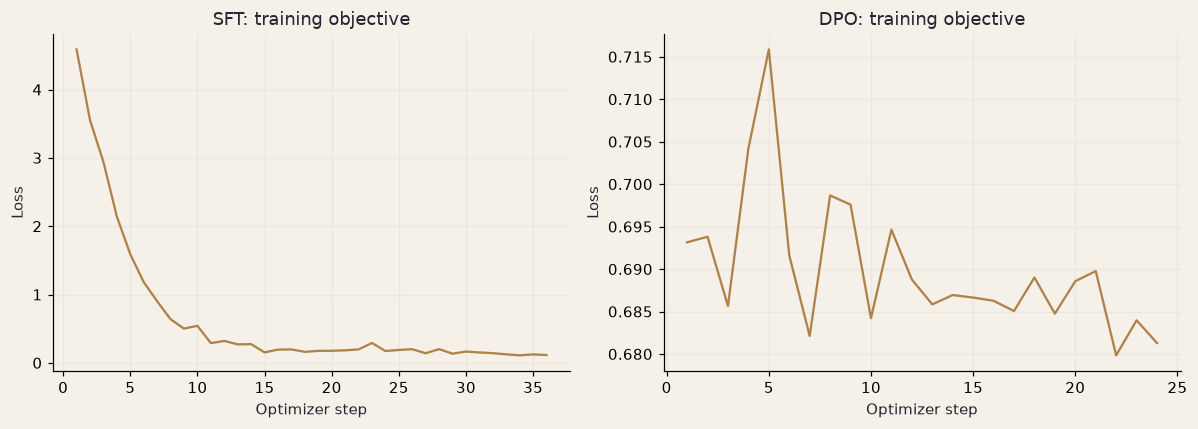

| Prompt | Expected | Pretrained | SFT | DPO |
|---|---|---|---|---|
| The service was wonderful. | positive | The service was excellent | positive | positive |
| The music was wonderful. | positive | Positive<br><br>The | positive | positive |
| The service was awful. | negative | The service was awful | negative | negative |
| The music was awful. | negative | The music was awful | negative | negative |

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (stage, loss) in zip(axes, result['losses'].items()):
    ax.plot(np.arange(1, len(loss)+1), loss)
    ax.set(title=f'{stage}: training objective', xlabel='Optimizer step', ylabel='Loss')
plt.tight_layout(); plt.show()
table(['Prompt', 'Expected', 'Pretrained', 'SFT', 'DPO'],
      [[result['test'][i]['prompt'].split('Review: ')[1].split('\n')[0],
        result['test'][i]['chosen'].strip()] + [result['examples'][stage][i] for stage in ('Pretrained', 'SFT', 'DPO')]
       for i in [0, 1, 12, 13]])

## 3. Checks that protect the objective

Adding masked padding must not change completion likelihood. At the first DPO step, policy
and SFT reference match, so the loss is log(2); the implementation asserts this independently
of whether the sentiment classifier improves. Training success is not asserted by cherry-picking examples.

In [5]:
model, tokenizer = result['model'], result['tokenizer']
batch = mini_llm.batch_tokens(tokenizer, result['test'][:2])
ids, attention, completion_mask = batch
padded = (torch.nn.functional.pad(ids, (0, 3), value=tokenizer.pad_token_id),
          torch.nn.functional.pad(attention, (0, 3)), torch.nn.functional.pad(completion_mask, (0, 3)))
with torch.no_grad():
    before = mini_llm.completion_logps(model, batch)
    after = mini_llm.completion_logps(model, padded)
assert torch.allclose(before, after, atol=1e-4)
assert (completion_mask[:, 0] == 0).all()
print('PASS: shifted completion mask and padding invariance')

PASS: shifted completion mask and padding invariance


## Failure modes and extensions

**Reward artifact:** our synthetic preference rule equates one label with success. Longer explanations
or sarcasm are outside its coverage. **Overoptimization:** DPO loss can fall after generated-label
accuracy saturates; large margins are not additional task success. **Distribution shift:** evaluate
negation, mixed sentiment, and different prompt formats separately before making broader claims.

1. Increase DPO steps. Does the margin improve while exact accuracy remains unchanged or falls?
2. Add a negated-review test set without training on it. Report the new failure rate separately.
3. Compare summed and averaged response log probabilities on unequal-length responses. Explain the objective change.
4. Explain why cached reference scores must be recomputed if the reference checkpoint or tokenization changes.

References: [DPO](https://arxiv.org/abs/2305.18290), [InstructGPT](https://arxiv.org/abs/2203.02155),
[reward-model overoptimization](https://arxiv.org/abs/2210.10760).

[Next: verifiable rewards and group-relative updates →](10_verifiable_reasoning_grpo.ipynb)